# Schaefer Atlas Network Selection: DMN and Limbic Networks

This notebook demonstrates how to:
1. Load the Schaefer 2018 atlas (200 ROIs, 7 Yeo networks)
2. Extract specific functional networks (DMN and Limbic)
3. Extract and visualize timeseries data before and after network selection
4. Compare different network extractions

We'll use a real fMRI sample from the DELCODE dataset.

In [1]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker
import nibabel as nib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

## Part 1: Load the Schaefer Atlas

The Schaefer 2018 atlas provides a parcellation aligned to functional networks. We'll use:
- **200 ROIs**: Regions of interest (parcels)
- **7 Yeo Networks**: Default Mode, Dorsal Attention, Salience, Control, Limbic, Somatomotor, Visual
- **2mm resolution**: Spatial resolution of the atlas

In [2]:
# Fetch the Schaefer 2018 atlas
print("Loading Schaefer 2018 atlas...")
atlas_data = datasets.fetch_atlas_schaefer_2018(
    n_rois=200,          # 100 / 200 / 400 / 600 / 1000
    yeo_networks=7,      # aligns parcels to Yeo networks
    resolution_mm=2      # 2mm voxel size
)

# Load the atlas maps as a NIfTI image
atlas_maps = nib.load(atlas_data.maps)
labels = np.array(atlas_data.labels)

print(f"\n✓ Atlas loaded successfully!")
print(f"  Atlas shape: {atlas_maps.shape}")
print(f"  Number of ROIs: {len(labels)}")
print(f"  Number of networks: 7 (Yeo networks)")

# Display sample labels
print(f"\nSample labels (first 5):")
for i, label in enumerate(labels[:5]):
    # Handle both bytes and string labels
    if isinstance(label, bytes):
        label_str = label.decode('utf-8')
    else:
        label_str = str(label)
    print(f"  ROI {i}: {label_str}")

Loading Schaefer 2018 atlas...
[fetch_atlas_schaefer_2018] Dataset found in /home/wunderlich/nilearn_data/schaefer_2018

✓ Atlas loaded successfully!
  Atlas shape: (91, 109, 91)
  Number of ROIs: 201
  Number of networks: 7 (Yeo networks)

Sample labels (first 5):
  ROI 0: Background
  ROI 1: 7Networks_LH_Vis_1
  ROI 2: 7Networks_LH_Vis_2
  ROI 3: 7Networks_LH_Vis_3
  ROI 4: 7Networks_LH_Vis_4


In [3]:
# Identify all available networks and their ROIs
print("Network Summary:")
print("=" * 60)

networks = {}
for i, label in enumerate(labels):
    # Handle both bytes and string labels
    if isinstance(label, bytes):
        label_str = label.decode('utf-8')
    else:
        label_str = str(label)
    
    # Extract network name from label (format: 7Networks_RX_NetworkName)
    parts = label_str.split('_')
    if len(parts) >= 3:
        network = '_'.join(parts[2:])  # Get everything after Network index
    else:
        network = "Unknown"
    
    if network not in networks:
        networks[network] = []
    networks[network].append(i)

for network_name in sorted(networks.keys()):
    roi_indices = networks[network_name]
    print(f"\n{network_name}:")
    print(f"  ROI indices: {roi_indices}")
    print(f"  Number of ROIs: {len(roi_indices)}")

Network Summary:

Cont_Cing_1:
  ROI indices: [72, 178]
  Number of ROIs: 2

Cont_Cing_2:
  ROI indices: [73, 179]
  Number of ROIs: 2

Cont_OFC_1:
  ROI indices: [65]
  Number of ROIs: 1

Cont_PFCl_1:
  ROI indices: [66, 170]
  Number of ROIs: 2

Cont_PFCl_2:
  ROI indices: [67, 171]
  Number of ROIs: 2

Cont_PFCl_3:
  ROI indices: [68, 172]
  Number of ROIs: 2

Cont_PFCl_4:
  ROI indices: [69, 173]
  Number of ROIs: 2

Cont_PFCl_5:
  ROI indices: [70, 174]
  Number of ROIs: 2

Cont_PFCl_6:
  ROI indices: [175]
  Number of ROIs: 1

Cont_PFCl_7:
  ROI indices: [176]
  Number of ROIs: 1

Cont_PFCmp_1:
  ROI indices: [180]
  Number of ROIs: 1

Cont_PFCmp_2:
  ROI indices: [181]
  Number of ROIs: 1

Cont_PFCv_1:
  ROI indices: [169]
  Number of ROIs: 1

Cont_Par_1:
  ROI indices: [61, 165]
  Number of ROIs: 2

Cont_Par_2:
  ROI indices: [62, 166]
  Number of ROIs: 2

Cont_Par_3:
  ROI indices: [63, 167]
  Number of ROIs: 2

Cont_Temp_1:
  ROI indices: [64, 168]
  Number of ROIs: 2

Cont_p

## Part 2: Load Sample fMRI Data

Now we'll load a real fMRI sample from the DELCODE dataset and extract brain activity timeseries.

In [4]:
# Load the sample fMRI file
fmri_path = "/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v0__/fmri/AD_postprocessed_v0/sub-1b6c308bb/ses-01/"
fmri_file = fmri_path + "sub-1b6c308bb_ses-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-ICAAROMA2Phys1GS_bold_reoriented.nii.gz"

print(f"Loading fMRI data from:")
print(f"  {fmri_file}")

# Load the NIfTI file
img = nib.load(fmri_file)
fmri_data = img.get_fdata()
print(f"\n✓ fMRI data loaded successfully!")
print(f"  Shape (voxels × time): {fmri_data.shape}")
print(f"  Number of timepoints: {fmri_data.shape[3]}")
print(f"  Voxel dimensions: {img.header.get_zooms()[:3]} mm")

Loading fMRI data from:
  /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v0__/fmri/AD_postprocessed_v0/sub-1b6c308bb/ses-01/sub-1b6c308bb_ses-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-ICAAROMA2Phys1GS_bold_reoriented.nii.gz

✓ fMRI data loaded successfully!
  Shape (voxels × time): (97, 115, 97, 170)
  Number of timepoints: 170
  Voxel dimensions: (np.float32(2.0), np.float32(2.0), np.float32(2.0)) mm


In [5]:
# Extract timeseries for ALL ROIs using the atlas
print("\nExtracting timeseries from all ROIs...")
masker = NiftiLabelsMasker(labels_img=atlas_maps, standardize=True)
timeseries_all = masker.fit_transform(img)

print(f"✓ Timeseries extracted!")
print(f"  Shape (timepoints × ROIs): {timeseries_all.shape}")
print(f"  Data type: {timeseries_all.dtype}")

# Show basic statistics
print(f"\nTimeseries Statistics (across all ROIs):")
print(f"  Mean: {timeseries_all.mean():.4f}")
print(f"  Std Dev: {timeseries_all.std():.4f}")
print(f"  Min: {timeseries_all.min():.4f}")
print(f"  Max: {timeseries_all.max():.4f}")


Extracting timeseries from all ROIs...
✓ Timeseries extracted!
  Shape (timepoints × ROIs): (170, 200)
  Data type: float64

Timeseries Statistics (across all ROIs):
  Mean: 0.0000
  Std Dev: 1.0000
  Min: -4.5700
  Max: 3.9077


## Part 3: Visualization - ALL ROIs (Before Selection)

Let's visualize the activity from all 200 ROIs across all timepoints. This shows the raw extracted data.

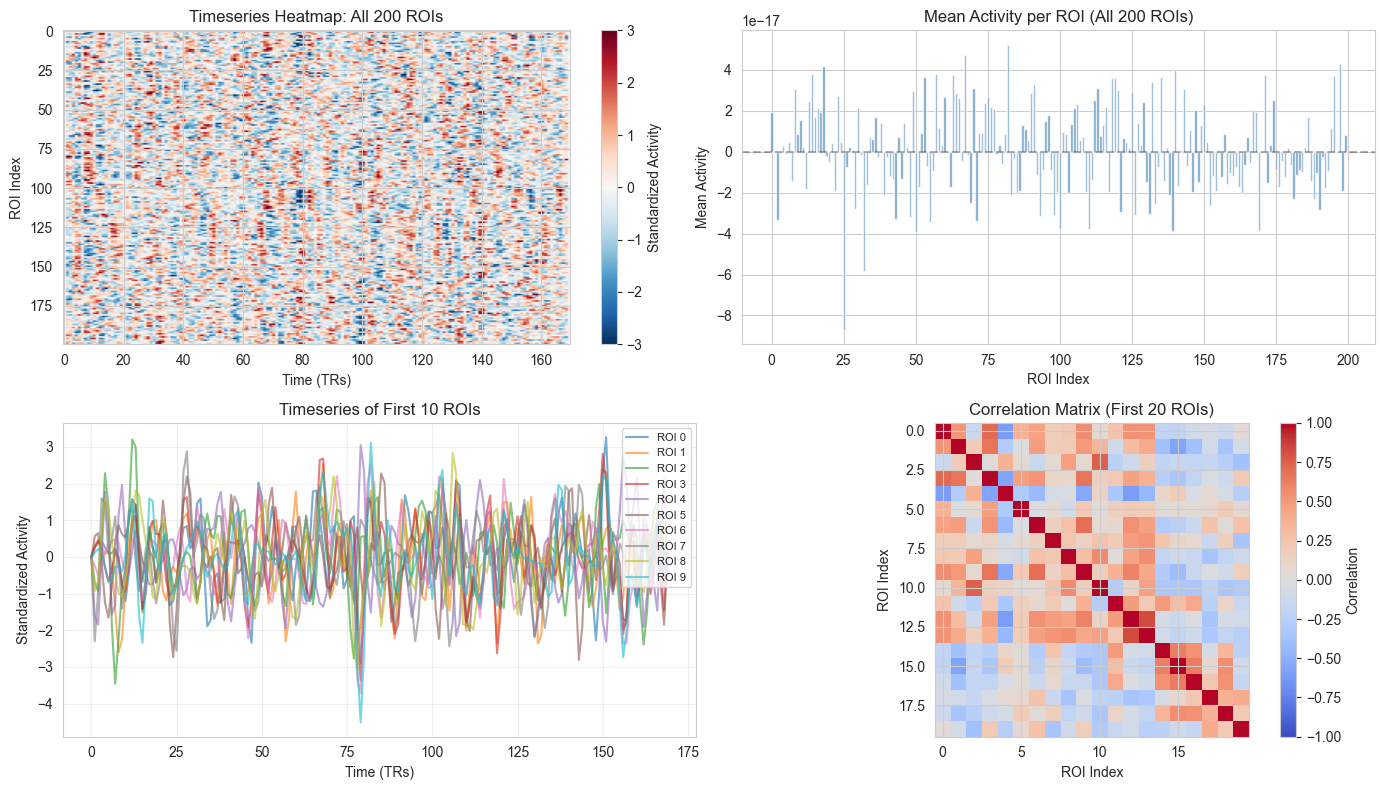

Visualization created for all 200 ROIs


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Heatmap of all ROIs
ax = axes[0, 0]
im = ax.imshow(timeseries_all.T, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
ax.set_xlabel('Time (TRs)')
ax.set_ylabel('ROI Index')
ax.set_title('Timeseries Heatmap: All 200 ROIs')
plt.colorbar(im, ax=ax, label='Standardized Activity')

# 2. Mean activity across time for each ROI
ax = axes[0, 1]
roi_means = timeseries_all.mean(axis=0)
ax.bar(range(len(roi_means)), roi_means, color='steelblue', alpha=0.7)
ax.set_xlabel('ROI Index')
ax.set_ylabel('Mean Activity')
ax.set_title('Mean Activity per ROI (All 200 ROIs)')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# 3. Time series of first 10 ROIs
ax = axes[1, 0]
for i in range(min(10, timeseries_all.shape[1])):
    ax.plot(timeseries_all[:, i], alpha=0.6, label=f'ROI {i}')
ax.set_xlabel('Time (TRs)')
ax.set_ylabel('Standardized Activity')
ax.set_title('Timeseries of First 10 ROIs')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

# 4. Correlation matrix (subset for visibility)
ax = axes[1, 1]
roi_subset = 20  # Show only first 20 ROIs for clarity
corr_matrix = np.corrcoef(timeseries_all[:, :roi_subset].T)
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xlabel('ROI Index')
ax.set_ylabel('ROI Index')
ax.set_title(f'Correlation Matrix (First {roi_subset} ROIs)')
plt.colorbar(im, ax=ax, label='Correlation')

plt.tight_layout()
plt.show()

print(f"Visualization created for all {timeseries_all.shape[1]} ROIs")

## Part 4: DMN Network Selection

The Default Mode Network (DMN) is one of the most studied functional networks. It includes brain regions that show greater activity at rest and decrease during task engagement (e.g., medial prefrontal cortex, posterior cingulate cortex).

We'll now select only the ROIs that belong to the DMN network.

In [7]:
# Select DMN ROIs
# The DMN contains all ROIs with 'Default' in their label
# Skip index 0 (background) - the masker doesn't extract it
dmn_indices = []
for i, lab in enumerate(labels):
    # Skip background (index 0)
    if i == 0:
        continue
    
    # Handle both bytes and string labels
    if isinstance(lab, bytes):
        label_str = lab.decode('utf-8')
    else:
        label_str = str(lab)
    if 'Default' in label_str:
        dmn_indices.append(i - 1)  # -1 because masker skips background

dmn_timeseries = timeseries_all[:, dmn_indices]

print("=" * 60)
print("DEFAULT MODE NETWORK (DMN) SELECTION")
print("=" * 60)
print(f"\nDMN ROI indices (in full atlas): {[i+1 for i in dmn_indices]}")
print(f"DMN ROI indices (in masker output): {dmn_indices}")
print(f"Number of DMN ROIs: {len(dmn_indices)}")
print(f"Percentage of total ROIs: {len(dmn_indices)/200*100:.1f}%")

# Show DMN labels
print(f"\nDMN ROI Labels:")
for i, atlas_idx in enumerate([i+1 for i in dmn_indices]):
    label = labels[atlas_idx]
    if isinstance(label, bytes):
        label_str = label.decode('utf-8')
    else:
        label_str = str(label)
    print(f"  {i+1}. ROI {atlas_idx}: {label_str}")

# Statistics for DMN
print(f"\nDMN Timeseries Statistics:")
print(f"  Shape (timepoints × DMN ROIs): {dmn_timeseries.shape}")
print(f"  Mean activity: {dmn_timeseries.mean():.4f}")
print(f"  Std Dev: {dmn_timeseries.std():.4f}")
print(f"  Min activity: {dmn_timeseries.min():.4f}")
print(f"  Max activity: {dmn_timeseries.max():.4f}")

DEFAULT MODE NETWORK (DMN) SELECTION

DMN ROI indices (in full atlas): [74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]
DMN ROI indices (in masker output): [73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199]
Number of DMN ROIs: 46
Percentage of total ROIs: 23.0%

DMN ROI Labels:
  1. ROI 74: 7Networks_LH_Default_Temp_1
  2. ROI 75: 7Networks_LH_Default_Temp_2
  3. ROI 76: 7Networks_LH_Default_Temp_3
  4. ROI 77: 7Networks_LH_Default_Temp_4
  5. ROI 78: 7Networks_LH_Default_Temp_5
  6. ROI 79: 7Networks_LH_Default_Par_1
  7. ROI 80: 7Networks_LH_Default_Par_2
  8. ROI 81: 7Networks_LH_Default_Par_3
  9. ROI 82: 7Networks_LH_Default_Par_4
  10. ROI 83: 7Networks_LH_Default_PFC_1
  11. 

### Visualization: DMN Network (After Selection)

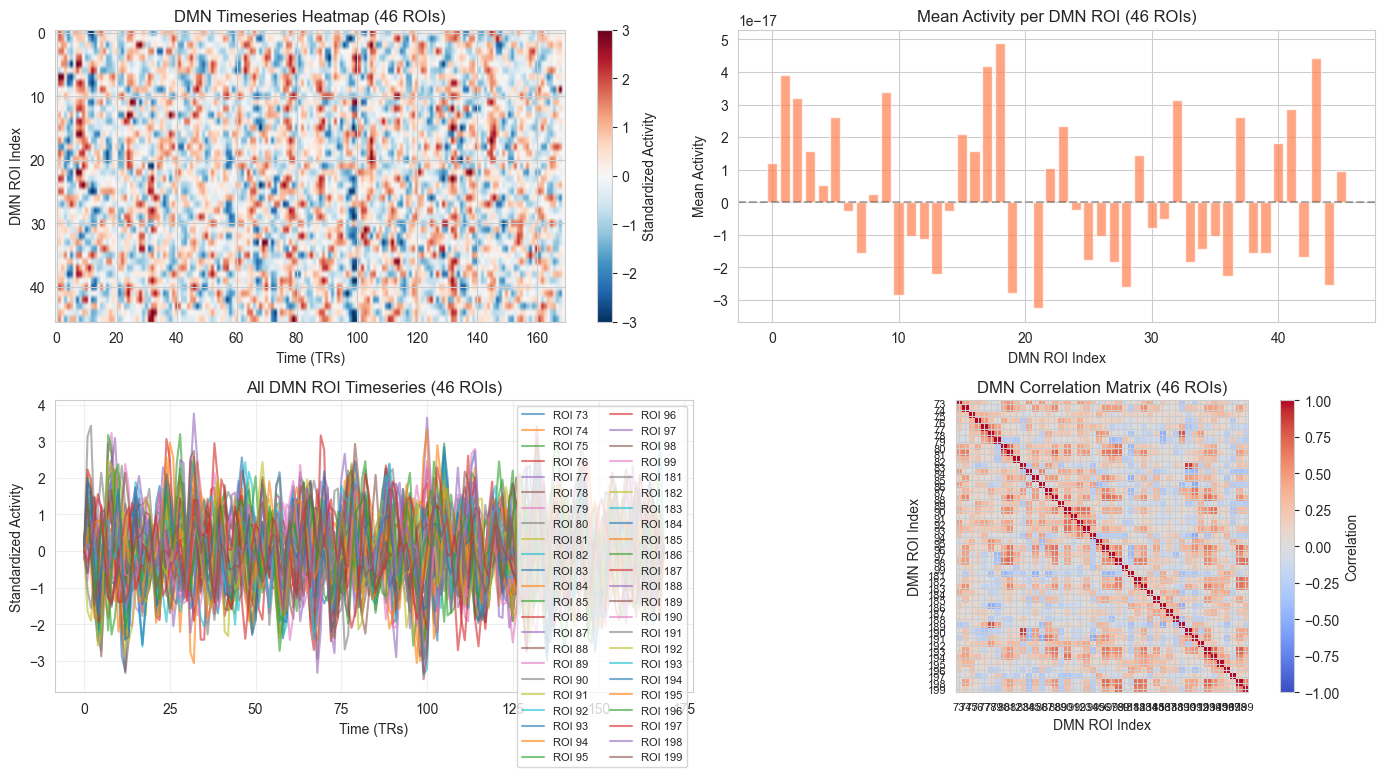

✓ DMN visualization created


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Heatmap of DMN ROIs
ax = axes[0, 0]
im = ax.imshow(dmn_timeseries.T, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
ax.set_xlabel('Time (TRs)')
ax.set_ylabel('DMN ROI Index')
ax.set_title(f'DMN Timeseries Heatmap ({len(dmn_indices)} ROIs)')
plt.colorbar(im, ax=ax, label='Standardized Activity')

# 2. Mean activity across time for each DMN ROI
ax = axes[0, 1]
roi_means_dmn = dmn_timeseries.mean(axis=0)
ax.bar(range(len(roi_means_dmn)), roi_means_dmn, color='coral', alpha=0.7)
ax.set_xlabel('DMN ROI Index')
ax.set_ylabel('Mean Activity')
ax.set_title(f'Mean Activity per DMN ROI ({len(dmn_indices)} ROIs)')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# 3. All DMN timeseries overlaid
ax = axes[1, 0]
for i in range(dmn_timeseries.shape[1]):
    ax.plot(dmn_timeseries[:, i], alpha=0.6, label=f'ROI {dmn_indices[i]}')
ax.set_xlabel('Time (TRs)')
ax.set_ylabel('Standardized Activity')
ax.set_title(f'All DMN ROI Timeseries ({len(dmn_indices)} ROIs)')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(alpha=0.3)

# 4. DMN correlation matrix
ax = axes[1, 1]
corr_matrix_dmn = np.corrcoef(dmn_timeseries.T)
im = ax.imshow(corr_matrix_dmn, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xlabel('DMN ROI Index')
ax.set_ylabel('DMN ROI Index')
ax.set_title(f'DMN Correlation Matrix ({len(dmn_indices)} ROIs)')
# Set tick labels to actual ROI indices
tick_positions = range(len(dmn_indices))
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels([str(dmn_indices[i]) for i in tick_positions], fontsize=8)
ax.set_yticklabels([str(dmn_indices[i]) for i in tick_positions], fontsize=8)
plt.colorbar(im, ax=ax, label='Correlation')

plt.tight_layout()
plt.show()

print(f"✓ DMN visualization created")

### Spatial Localization: DMN Regions (Brain Slices + 3D)

This view maps the selected DMN parcels back into anatomical space using the Schaefer atlas labels.

- `dmn_indices` are indices in masker output space (0..199)
- Atlas label values are shifted by +1 because label `0` is background

DMN spatial mask summary:
  DMN ROIs (masker space): 46
  DMN atlas label values: [74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]
  Non-zero voxels in DMN mask: 33823


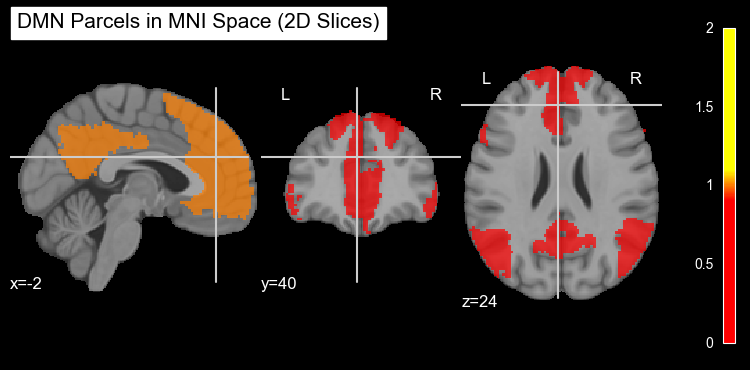

In [9]:
# Build a DMN binary mask in atlas space
atlas_data = atlas_maps.get_fdata()
dmn_atlas_labels = np.array(dmn_indices) + 1  # +1 to map from masker indices to atlas label values

dmn_mask_data = np.isin(atlas_data, dmn_atlas_labels).astype(np.int16)
dmn_mask_img = nib.Nifti1Image(dmn_mask_data, atlas_maps.affine, atlas_maps.header)

print("DMN spatial mask summary:")
print(f"  DMN ROIs (masker space): {len(dmn_indices)}")
print(f"  DMN atlas label values: {dmn_atlas_labels.tolist()}")
print(f"  Non-zero voxels in DMN mask: {int(dmn_mask_data.sum())}")

# 2D orthogonal brain slices
plotting.plot_roi(
    dmn_mask_img,
    bg_img=datasets.load_mni152_template(),
    display_mode='ortho',
    draw_cross=True,
    title='DMN Parcels in MNI Space (2D Slices)',
    cmap='autumn'
)
plotting.show()

In [10]:
# Interactive 3D view (if supported by the notebook renderer)
print("Rendering interactive DMN 3D view...")

try:
    dmn_view = plotting.view_img(
        dmn_mask_img,
        bg_img=datasets.load_mni152_template(),
        threshold=0.5,
        cmap='autumn',
        opacity=0.65,
        title='DMN Parcels (Interactive 3D)'
    )
    dmn_view
except Exception as e:
    print("Interactive 3D rendering is not available in this environment.")
    print(f"Reason: {e}")

Rendering interactive DMN 3D view...


## Part 5: Limbic Network Selection

The Limbic Network is involved in emotion regulation and reward processing. Key regions include the amygdala, hippocampus, and orbitofrontal cortex. This is another important network for understanding neurological conditions like AD.

We'll now apply the same extraction and visualization process to the Limbic network.

In [11]:
# Select Limbic ROIs
# The Limbic network contains all ROIs with 'Limbic' in their label
# Skip index 0 (background) - the masker doesn't extract it
limbic_indices = []
for i, lab in enumerate(labels):
    # Skip background (index 0)
    if i == 0:
        continue
    
    # Handle both bytes and string labels
    if isinstance(lab, bytes):
        label_str = lab.decode('utf-8')
    else:
        label_str = str(lab)
    if 'Limbic' in label_str:
        limbic_indices.append(i - 1)  # -1 because masker skips background

limbic_timeseries = timeseries_all[:, limbic_indices]

print("=" * 60)
print("LIMBIC NETWORK SELECTION")
print("=" * 60)
print(f"\nLimbic ROI indices (in full atlas): {[i+1 for i in limbic_indices]}")
print(f"Limbic ROI indices (in masker output): {limbic_indices}")
print(f"Number of Limbic ROIs: {len(limbic_indices)}")
print(f"Percentage of total ROIs: {len(limbic_indices)/200*100:.1f}%")

# Show Limbic labels
print(f"\nLimbic ROI Labels:")
for i, atlas_idx in enumerate([i+1 for i in limbic_indices]):
    label = labels[atlas_idx]
    if isinstance(label, bytes):
        label_str = label.decode('utf-8')
    else:
        label_str = str(label)
    print(f"  {i+1}. ROI {atlas_idx}: {label_str}")

# Statistics for Limbic
print(f"\nLimbic Timeseries Statistics:")
print(f"  Shape (timepoints × Limbic ROIs): {limbic_timeseries.shape}")
print(f"  Mean activity: {limbic_timeseries.mean():.4f}")
print(f"  Std Dev: {limbic_timeseries.std():.4f}")
print(f"  Min activity: {limbic_timeseries.min():.4f}")
print(f"  Max activity: {limbic_timeseries.max():.4f}")

LIMBIC NETWORK SELECTION

Limbic ROI indices (in full atlas): [55, 56, 57, 58, 59, 60, 159, 160, 161, 162, 163, 164]
Limbic ROI indices (in masker output): [54, 55, 56, 57, 58, 59, 158, 159, 160, 161, 162, 163]
Number of Limbic ROIs: 12
Percentage of total ROIs: 6.0%

Limbic ROI Labels:
  1. ROI 55: 7Networks_LH_Limbic_OFC_1
  2. ROI 56: 7Networks_LH_Limbic_OFC_2
  3. ROI 57: 7Networks_LH_Limbic_TempPole_1
  4. ROI 58: 7Networks_LH_Limbic_TempPole_2
  5. ROI 59: 7Networks_LH_Limbic_TempPole_3
  6. ROI 60: 7Networks_LH_Limbic_TempPole_4
  7. ROI 159: 7Networks_RH_Limbic_OFC_1
  8. ROI 160: 7Networks_RH_Limbic_OFC_2
  9. ROI 161: 7Networks_RH_Limbic_OFC_3
  10. ROI 162: 7Networks_RH_Limbic_TempPole_1
  11. ROI 163: 7Networks_RH_Limbic_TempPole_2
  12. ROI 164: 7Networks_RH_Limbic_TempPole_3

Limbic Timeseries Statistics:
  Shape (timepoints × Limbic ROIs): (170, 12)
  Mean activity: -0.0000
  Std Dev: 1.0000
  Min activity: -3.8727
  Max activity: 3.6995


### Visualization: Limbic Network (After Selection)

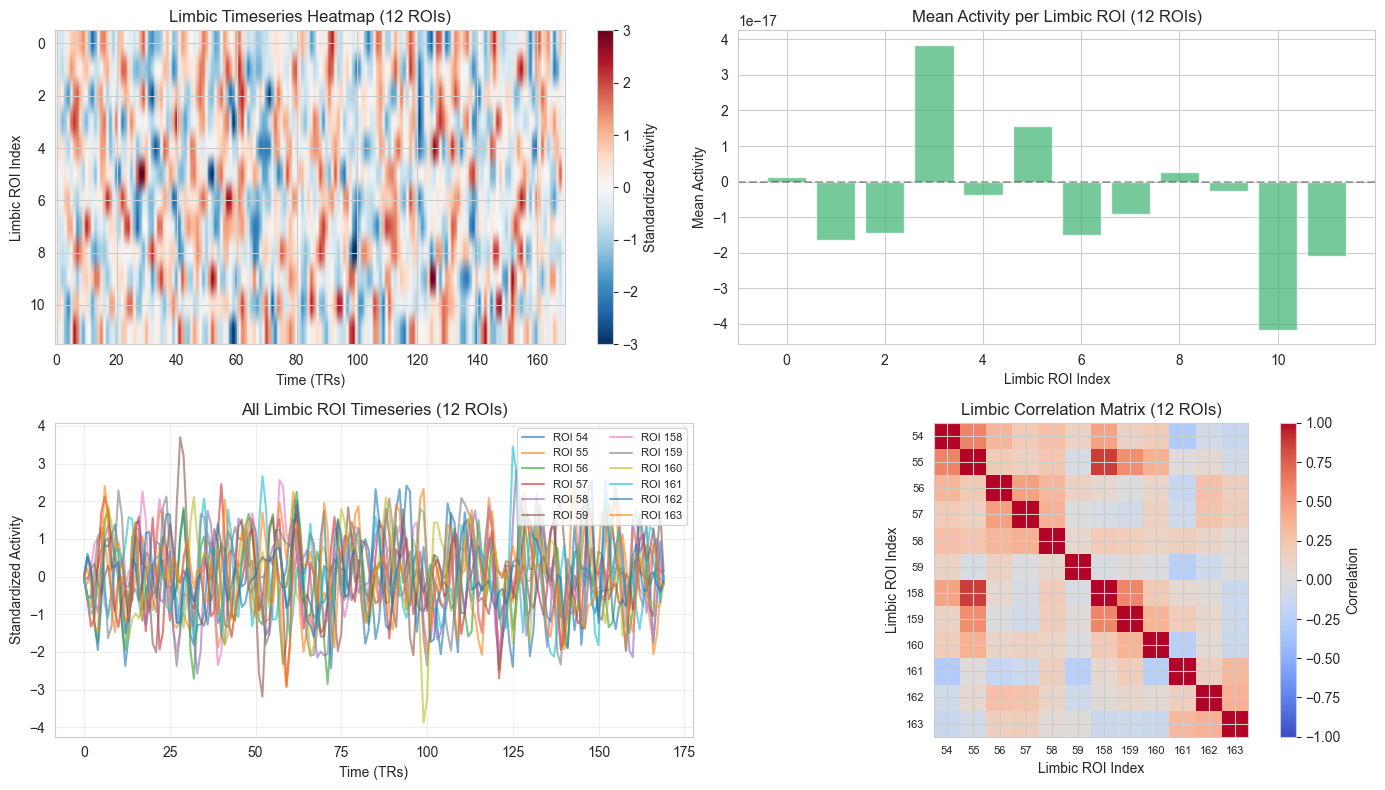

✓ Limbic visualization created


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Heatmap of Limbic ROIs
ax = axes[0, 0]
im = ax.imshow(limbic_timeseries.T, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
ax.set_xlabel('Time (TRs)')
ax.set_ylabel('Limbic ROI Index')
ax.set_title(f'Limbic Timeseries Heatmap ({len(limbic_indices)} ROIs)')
plt.colorbar(im, ax=ax, label='Standardized Activity')

# 2. Mean activity across time for each Limbic ROI
ax = axes[0, 1]
roi_means_limbic = limbic_timeseries.mean(axis=0)
ax.bar(range(len(roi_means_limbic)), roi_means_limbic, color='mediumseagreen', alpha=0.7)
ax.set_xlabel('Limbic ROI Index')
ax.set_ylabel('Mean Activity')
ax.set_title(f'Mean Activity per Limbic ROI ({len(limbic_indices)} ROIs)')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# 3. All Limbic timeseries overlaid
ax = axes[1, 0]
for i in range(limbic_timeseries.shape[1]):
    ax.plot(limbic_timeseries[:, i], alpha=0.6, label=f'ROI {limbic_indices[i]}')
ax.set_xlabel('Time (TRs)')
ax.set_ylabel('Standardized Activity')
ax.set_title(f'All Limbic ROI Timeseries ({len(limbic_indices)} ROIs)')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(alpha=0.3)

# 4. Limbic correlation matrix
ax = axes[1, 1]
corr_matrix_limbic = np.corrcoef(limbic_timeseries.T)
im = ax.imshow(corr_matrix_limbic, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xlabel('Limbic ROI Index')
ax.set_ylabel('Limbic ROI Index')
ax.set_title(f'Limbic Correlation Matrix ({len(limbic_indices)} ROIs)')
# Set tick labels to actual ROI indices
tick_positions = range(len(limbic_indices))
ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)
ax.set_xticklabels([str(limbic_indices[i]) for i in tick_positions], fontsize=8)
ax.set_yticklabels([str(limbic_indices[i]) for i in tick_positions], fontsize=8)
plt.colorbar(im, ax=ax, label='Correlation')

plt.tight_layout()
plt.show()

print(f"✓ Limbic visualization created")

### Spatial Localization: Limbic Regions (Brain Slices + 3D)

This view maps selected Limbic parcels back to anatomy in MNI space.

- `limbic_indices` are masker-space indices (0..199)
- Atlas label values are `limbic_indices + 1` (background is label `0`)

Limbic spatial mask summary:
  Limbic ROIs (masker space): 12
  Limbic atlas label values: [55, 56, 57, 58, 59, 60, 159, 160, 161, 162, 163, 164]
  Non-zero voxels in Limbic mask: 9959


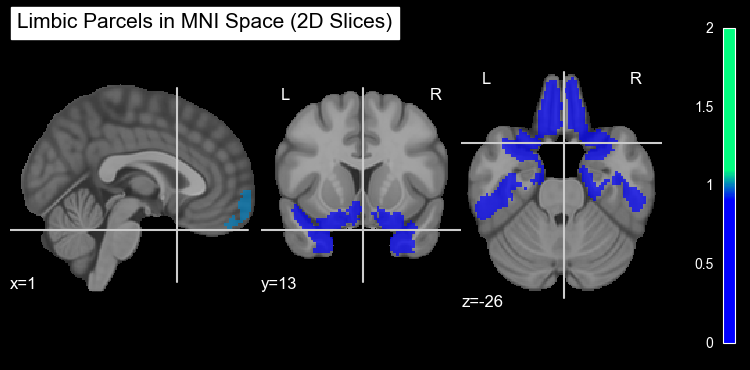

In [13]:
# Build a Limbic binary mask in atlas space
atlas_data = atlas_maps.get_fdata()
limbic_atlas_labels = np.array(limbic_indices) + 1  # +1 to map from masker indices to atlas label values

limbic_mask_data = np.isin(atlas_data, limbic_atlas_labels).astype(np.int16)
limbic_mask_img = nib.Nifti1Image(limbic_mask_data, atlas_maps.affine, atlas_maps.header)

print("Limbic spatial mask summary:")
print(f"  Limbic ROIs (masker space): {len(limbic_indices)}")
print(f"  Limbic atlas label values: {limbic_atlas_labels.tolist()}")
print(f"  Non-zero voxels in Limbic mask: {int(limbic_mask_data.sum())}")

# 2D orthogonal brain slices
plotting.plot_roi(
    limbic_mask_img,
    bg_img=datasets.load_mni152_template(),
    display_mode='ortho',
    draw_cross=True,
    title='Limbic Parcels in MNI Space (2D Slices)',
    cmap='winter'
)
plotting.show()

In [14]:
# Interactive 3D view (if supported by the notebook renderer)
print("Rendering interactive Limbic 3D view...")

try:
    limbic_view = plotting.view_img(
        limbic_mask_img,
        bg_img=datasets.load_mni152_template(),
        threshold=0.5,
        cmap='winter',
        opacity=0.65,
        title='Limbic Parcels (Interactive 3D)'
    )
    limbic_view
except Exception as e:
    print("Interactive 3D rendering is not available in this environment.")
    print(f"Reason: {e}")

Rendering interactive Limbic 3D view...


## Part 6: Comparison - DMN vs Limbic vs All ROIs

Let's compare the extracted networks side-by-side to understand their characteristics.

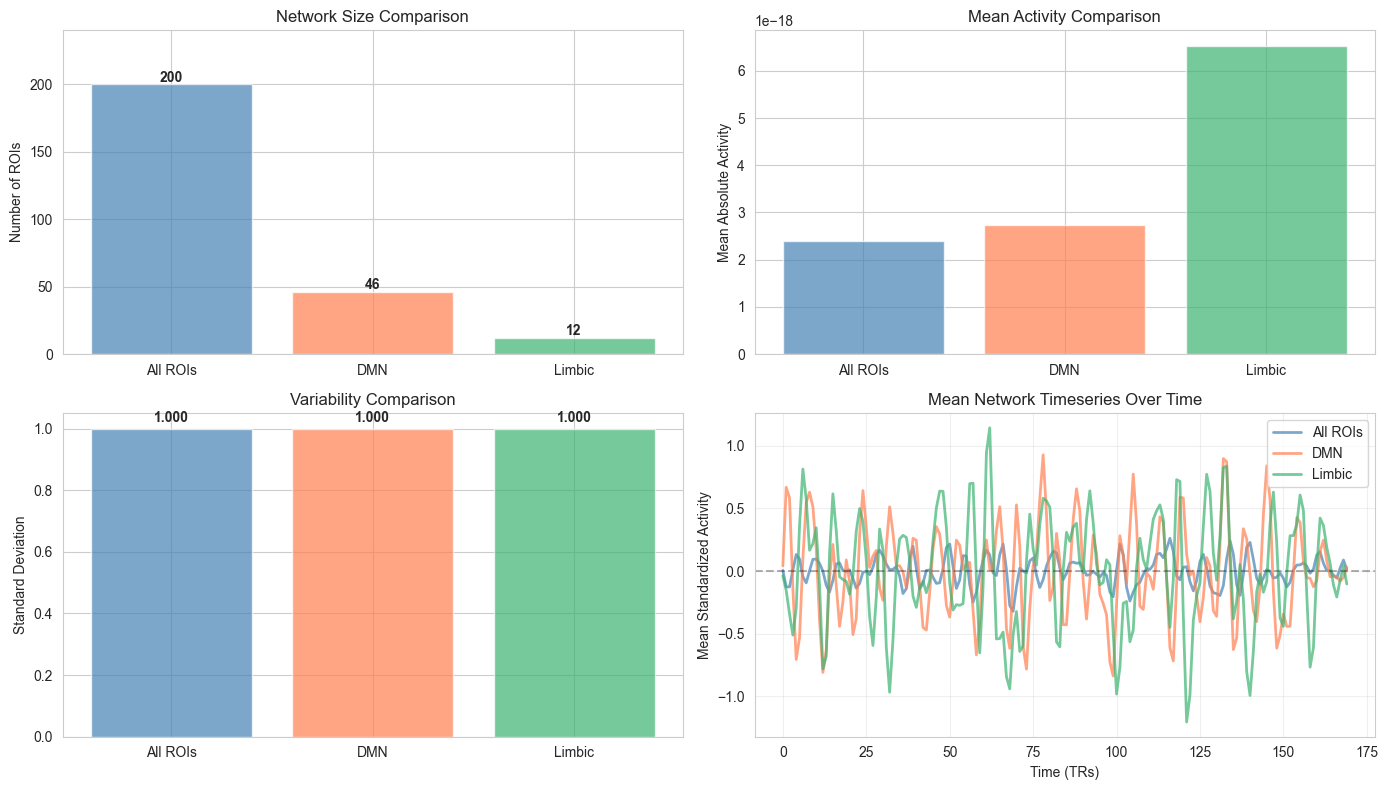

✓ Comparison visualization created


In [15]:
# Create summary statistics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Network size comparison
ax = axes[0, 0]
networks_data = {
    'All ROIs': timeseries_all.shape[1],
    'DMN': dmn_timeseries.shape[1],
    'Limbic': limbic_timeseries.shape[1]
}
colors_bar = ['steelblue', 'coral', 'mediumseagreen']
ax.bar(networks_data.keys(), networks_data.values(), color=colors_bar, alpha=0.7)
ax.set_ylabel('Number of ROIs')
ax.set_title('Network Size Comparison')
ax.set_ylim([0, max(networks_data.values()) * 1.2])
for i, (k, v) in enumerate(networks_data.items()):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold')

# 2. Mean activity comparison
ax = axes[0, 1]
mean_activities = {
    'All ROIs': np.abs(timeseries_all.mean()),
    'DMN': np.abs(dmn_timeseries.mean()),
    'Limbic': np.abs(limbic_timeseries.mean())
}
ax.bar(mean_activities.keys(), mean_activities.values(), color=colors_bar, alpha=0.7)
ax.set_ylabel('Mean Absolute Activity')
ax.set_title('Mean Activity Comparison')
for i, (k, v) in enumerate(mean_activities.items()):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 3. Std Dev comparison
ax = axes[1, 0]
std_devs = {
    'All ROIs': timeseries_all.std(),
    'DMN': dmn_timeseries.std(),
    'Limbic': limbic_timeseries.std()
}
ax.bar(std_devs.keys(), std_devs.values(), color=colors_bar, alpha=0.7)
ax.set_ylabel('Standard Deviation')
ax.set_title('Variability Comparison')
for i, (k, v) in enumerate(std_devs.items()):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 4. Mean timeseries comparison
ax = axes[1, 1]
all_mean_ts = timeseries_all.mean(axis=1)
dmn_mean_ts = dmn_timeseries.mean(axis=1)
limbic_mean_ts = limbic_timeseries.mean(axis=1)

ax.plot(all_mean_ts, alpha=0.7, linewidth=2, label='All ROIs', color='steelblue')
ax.plot(dmn_mean_ts, alpha=0.7, linewidth=2, label='DMN', color='coral')
ax.plot(limbic_mean_ts, alpha=0.7, linewidth=2, label='Limbic', color='mediumseagreen')
ax.set_xlabel('Time (TRs)')
ax.set_ylabel('Mean Standardized Activity')
ax.set_title('Mean Network Timeseries Over Time')
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Comparison visualization created")

## Part 7: Summary & Key Takeaways

### What We Learned:

1. **Atlas Structure**: The Schaefer 2018 atlas divides the brain into 200 ROIs organized into 7 functional networks based on resting-state connectivity (Yeo et al., 2011).

2. **Network Selection**: Functional networks can be extracted by filtering ROIs based on network labels. This allows us to focus on specific brain systems.

3. **DMN (Default Mode Network)**:
   - Critical for self-referential thinking and memory
   - Often affected in neurodegenerative diseases like Alzheimer's disease
   - More ROIs than Limbic network
   
4. **Limbic Network**:
   - Important for emotion, reward, and motivation
   - Includes regions like amygdala and hippocampus
   - Smaller network but highly relevant for AD phenotyping
   
5. **Timeseries Extraction**: Using `NiftiLabelsMasker`, we can efficiently extract mean timeseries for each ROI using the atlas labels.

6. **Standardization**: The masker applies z-score standardization, making activity comparable across regions with different baseline levels.

### Practical Applications:

- **Feature Engineering**: Extract network-level timeseries for machine learning models
- **Functional Connectivity**: Compute correlations between ROI timeseries to create connectivity matrices
- **Clinical Analysis**: Compare network activity patterns between AD patients, converters, and healthy controls
- **Dimensionality Reduction**: Instead of analyzing all voxels, work with 200 or fewer ROIs

## Part 8: Utility Functions for Reuse

Here are helper functions you can use to extract any network from the atlas:

In [16]:
def extract_network_timeseries(fmri_img, atlas_maps, labels, network_name):
    """
    Extract timeseries for a specific functional network.
    
    Parameters:
    -----------
    fmri_img : nibabel image
        4D fMRI image
    atlas_maps : nibabel image
        3D atlas with ROI labels
    labels : array
        Array of ROI labels (can be bytes or strings)
    network_name : str
        Network name to extract (must be in labels, e.g., 'Default', 'Limbic')
    
    Returns:
    --------
    timeseries : array (timepoints × ROIs)
        Extracted timeseries for the network
    indices : list
        ROI indices belonging to the network
    """
    # Find ROI indices
    indices = []
    for i, lab in enumerate(labels):
        if isinstance(lab, bytes):
            label_str = lab.decode('utf-8')
        else:
            label_str = str(lab)
        if network_name in label_str:
            indices.append(i)
    
    # Extract timeseries
    masker = NiftiLabelsMasker(labels_img=atlas_maps, standardize=True)
    full_timeseries = masker.fit_transform(fmri_img)
    network_timeseries = full_timeseries[:, indices]
    
    return network_timeseries, indices


def get_network_roi_labels(labels, network_name):
    """
    Get all ROI labels for a specific network.
    
    Parameters:
    -----------
    labels : array
        Array of ROI labels (can be bytes or strings)
    network_name : str
        Network name to extract
    
    Returns:
    --------
    roi_labels : list
        List of ROI labels for the network
    indices : list
        ROI indices
    """
    indices = []
    roi_labels = []
    for i, lab in enumerate(labels):
        if isinstance(lab, bytes):
            label_str = lab.decode('utf-8')
        else:
            label_str = str(lab)
        if network_name in label_str:
            indices.append(i)
            roi_labels.append(label_str)
    
    return roi_labels, indices


def list_available_networks(labels):
    """
    List all functional networks available in the atlas.
    
    Parameters:
    -----------
    labels : array
        Array of ROI labels (can be bytes or strings)
    
    Returns:
    --------
    networks : dict
        Dictionary with network names as keys and ROI indices as values
    """
    networks = {}
    for i, label in enumerate(labels):
        # Handle both bytes and string labels
        if isinstance(label, bytes):
            label_str = label.decode('utf-8')
        else:
            label_str = str(label)
        
        parts = label_str.split('_')
        if len(parts) >= 3:
            network = '_'.join(parts[2:])
        else:
            network = "Unknown"
        
        if network not in networks:
            networks[network] = []
        networks[network].append(i)
    
    return networks


# Example usage:
print("Available utility functions:")
print("  1. extract_network_timeseries() - Extract timeseries for any network")
print("  2. get_network_roi_labels() - Get labels for network ROIs")
print("  3. list_available_networks() - List all networks in atlas")
print("\nExample:")
print("  network_ts, indices = extract_network_timeseries(img, atlas_maps, labels, 'Somato')")
print("  labels, indices = get_network_roi_labels(labels, 'Dorsal_Attention')")

Available utility functions:
  1. extract_network_timeseries() - Extract timeseries for any network
  2. get_network_roi_labels() - Get labels for network ROIs
  3. list_available_networks() - List all networks in atlas

Example:
  network_ts, indices = extract_network_timeseries(img, atlas_maps, labels, 'Somato')
  labels, indices = get_network_roi_labels(labels, 'Dorsal_Attention')
